## 1. Пример импорта данных. Грузим данные

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            classification_report, confusion_matrix, 
                            roc_curve, precision_recall_curve, 
                            mean_absolute_error, mean_squared_error)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [43]:
data = pd.read_csv('../Downloads/apple_quality.csv')

## 2. Понимаем, какая перед нами задача

In [6]:
data.Quality.unique()

array(['good', 'bad', nan], dtype=object)

Анализ целевой переменной выявил наличие двух значимых классов (`good`, `bad`) и пропущенных значений (`NaN`). После обработки пропусков задача будет сведена к бинарной классификации, направленной на прогнозирование качества как `good` или `bad`.

---

## 3. Делаем предобработку данных

#### Предобработка data

In [92]:
columns_data = data.columns
for name in columns_data:
    if data[name].dtype in ['int64', 'float64', 'int32', 'float32']:
        print(f"{name}: \n{data[name].unique()}", f"\n\nDifference max/min: {data[name].max() - data[name].min()}")
        print('---')
    else:
        print(f"{name}: \n{data[name].unique()}")
        print('---')

A_id: 
[0.000e+00 1.000e+00 2.000e+00 ... 3.997e+03 3.998e+03 3.999e+03] 

Difference max/min: 3999.0
---
Size: 
[-3.97004852 -1.19521719 -0.29202386 ... -2.6345153  -4.00800374
  0.27853965] 

Difference max/min: 13.558069958
---
Weight: 
[-2.51233638 -2.83925653 -1.35128199 ... -2.13824672 -1.77933711
 -1.71550503] 

Difference max/min: 12.940561265
---
Sweetness: 
[ 5.34632961  3.66405876 -1.73842916 ... -2.44046129  2.36639697
  0.12121725] 

Difference max/min: 13.269401007
---
Crunchiness: 
[-1.01200871  1.58823231 -0.34261593 ...  0.65722289 -0.20032937
 -1.15407476] 

Difference max/min: 13.674909606
---
Juiciness: 
[1.84490036 0.8532858  2.83863551 ... 2.19970859 2.16143512 1.2666774 ] 

Difference max/min: 13.326299912
---
Ripeness: 
[ 0.3298398   0.86753008 -0.03803333 ...  4.76385918  0.21448838
 -0.77657147] 

Difference max/min: 13.102435602
---
Acidity: 
[-0.49159048 -0.72280937  2.62163647 ... -1.33461139 -2.22971981
  1.59979646] 

Difference max/min: 14.41527471299999

In [13]:
data.dtypes

A_id           float64
Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity         object
Quality         object
dtype: object

На основе анализа структуры данных выявлены следующие необходимые преобразования:

- Преобразование столбца `Acidity` из строкового формата (`object`) в числовой (`float64`)
- Бинарное кодирование целевой переменной `Quality` (замена `good`/`bad` на числовые значения)
- Обработка пропущенных значений (`NaN`) во всех числовых столбцах


Анализ числовых признаков показал, что **данные уже были предварительно масштабированы**, вероятно, с использованием Z-score нормализации. Все признаки находятся в сопоставимых диапазонах, что исключает необходимость дополнительного масштабирования перед обучением моделей.

---

In [44]:
data.tail()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good
4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Created_by_Nidula_Elgiriyewithana,NaN


In [45]:
data = data.drop(index=4000)

In [49]:
data['Quality'] = data['Quality'].map({'good' : 1, 'bad' : 0})

In [50]:
data.Quality.unique()

array([1, 0])

In [52]:
data['Acidity'] = data['Acidity'].astype(float)

In [54]:
data.Acidity.dtype

dtype('float64')

In [55]:
data.dtypes

A_id           float64
Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity        float64
Quality          int64
dtype: object

В процессе преобразования типов данных был выявлен и удален служебный артефакт в строке 4000, содержащий технический комментарий "Created_by_Nidula_Elgiriyewithana" и пропущенные значения во всех столбцах.

Было принято решение удалить строку 4000 как неинформативную и содержащую только служебные данные

---

Проверим на пропуски и разделим данные на train и test:

In [56]:
data.isna().sum()

A_id           0
Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64

In [58]:
X = data.drop(columns='Quality')
y = data.Quality

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## 3. Обучим на тренировочном множестве


In [67]:
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_depth10 = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_default = DecisionTreeClassifier(random_state=42)

tree_depth3.fit(X_train, y_train)
tree_depth5.fit(X_train, y_train)
tree_depth10.fit(X_train, y_train)
tree_default.fit(X_train, y_train)

knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
knn10 = KNeighborsClassifier(n_neighbors=10)

knn3.fit(X_train, y_train)
knn5.fit(X_train, y_train)
knn10.fit(X_train, y_train)

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4. Посчитаем метрики на train и test множествах

In [80]:
models = {
    'Logistic Regression': logreg,
    'Tree depth=3': tree_depth3, 
    'Tree depth=5': tree_depth5,
    'Tree depth=10': tree_depth10,
    'Tree default': tree_default,
    'KNN k=3': knn3,
    'KNN k=5': knn5,
    'KNN k=10': knn10,
    'Random Forest': forest
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': accuracy,
        'F1-score': f1, 
        'ROC-AUC': roc_auc
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

                     Accuracy  F1-score  ROC-AUC
Logistic Regression     0.745    0.7502   0.8322
Tree depth=3            0.688    0.7500   0.7673
Tree depth=5            0.741    0.7212   0.8352
Tree depth=10           0.804    0.8012   0.8368
Tree default            0.820    0.8211   0.8200
KNN k=3                 0.584    0.5720   0.5934
KNN k=5                 0.533    0.5399   0.5694
KNN k=10                0.544    0.4899   0.5581
Random Forest           0.891    0.8922   0.9547


### Лучшая модель: Random Forest
- Accuracy: 0.891 - наивысшая точность предсказаний
- F1-score: 0.892 - оптимальный баланс точности и полноты
- ROC-AUC: 0.955 - хорошая способность разделять классы

---

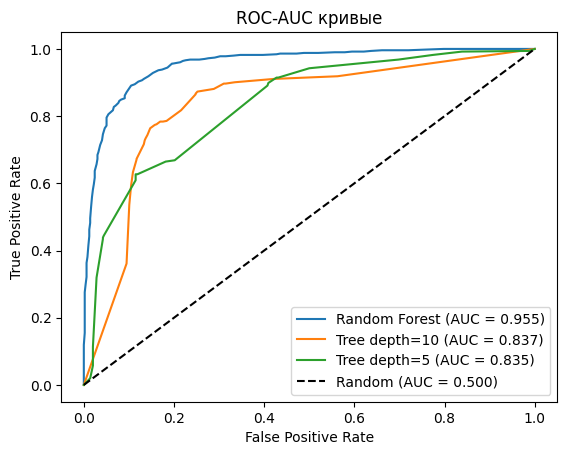

In [82]:
for name in best_models:
    model = models[name]
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC-AUC кривые')
plt.legend()
plt.show()

ROC-кривая показывает соотношение между `True Positive Rate` (чувствительность) и `False Positive Rate` (1 - специфичность). Площадь под кривой (AUC) количественно оценивает способность модели разделять классы.

`Random Forest` демонстрирует наилучший результат (AUC = 0.955), с кривой, наиболее приближенной к левому верхнему углу графика. Остальные модели располагаются ниже, что подтверждает лидерство `Random Forest` в способности эффективно разделять классы при минимальном уровне ложных срабатываний.

---

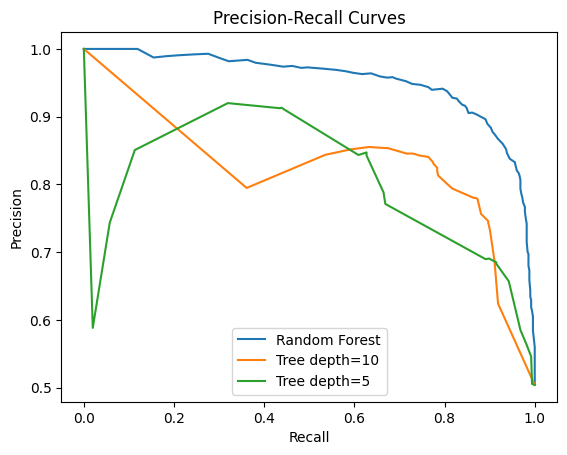

In [79]:
best_models = results_df.nlargest(3, 'ROC-AUC').index

for name in best_models:
    model = models[name]
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()

`Random Forest` подтверждает лидерство, обеспечивая оптимальный баланс между точностью предсказаний и полнотой охвата положительных примеров на всех порогах классификации.

---

## 5. Сравниваем метрики train/test и отвечаем на вопросы
     1. Какая модель справилась лучше с поставленной задачей?
     2. Имеет ли место переобучение?
     3. Имеет ли место недообучение?
     4. Как можно улучшить метрики моделей?

In [83]:
for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    difference = acc_train - acc_test
    print(f"{name}: train={acc_train:.3f}, test={acc_test:.3f}, diff={difference:.3f}")

Logistic Regression: train=0.751, test=0.745, diff=0.006
Tree depth=3: train=0.697, test=0.688, diff=0.009
Tree depth=5: train=0.772, test=0.741, diff=0.031
Tree depth=10: train=0.935, test=0.804, diff=0.131
Tree default: train=1.000, test=0.820, diff=0.180
KNN k=3: train=0.785, test=0.584, diff=0.201
KNN k=5: train=0.719, test=0.533, diff=0.186
KNN k=10: train=0.637, test=0.544, diff=0.093
Random Forest: train=1.000, test=0.891, diff=0.109


#### 1

Random Forest - показывает наилучший результат:

- Test Accuracy: 0.891 (максимальный)
- Переобучение: 0.109 (умеренное)

#### 2

Значительное переобучение наблюдается:

- Сильное: Tree default (0.180), KNN k=3 (0.201), KNN k=5 (0.186)
- Умеренное: Tree depth=10 (0.131), Random Forest (0.109)
- Минимальное: Logistic Regression (0.006), Tree depth=3 (0.009)

#### 3

Недообучение присутствует:

- KNN k=5 (test=0.533), KNN k=10 (test=0.544) - низкое качество
- Tree depth=3 (test=0.688) - удовлетворительно, но можно лучше

#### 4

Улучшить метрики можно:
- Подбор гиперпараметров через GridSearch
- Балансировка классов
- Добавление новых features

### Лучшая модель: Random Forest